In [ ]:
# %pip install torch
# %pip install numpy
# %pip install pygame
# %pip install stable-baselines3
# %pip install gymnasium
# %pip install tensorboard
# %pip install imageio[ffmpeg]

# **Load Environment**

In [ ]:
import sys
import numpy as np
sys.path.insert(0, '/content')

from wheelchair_env import WheelchairNavEnv
from stable_baselines3.common.env_checker import check_env

env = WheelchairNavEnv(action_type='continuous', seed=42)
check_env(env, warn=True)  # validates SB3 compatibility
obs, info = env.reset()
print('Obs shape:', obs.shape)
print('Action space:', env.action_space)


Obs shape: (7,)
Action space: Box(-1.5, 1.5, (1,), float32)


c:\Users\E\Desktop\code everything\Machine Learning\.venv\Lib\site-packages\stable_baselines3\common\env_checker.py:515: UserWarning: We recommend you to use a symmetric and normalized Box action space (range=[-1, 1]) cf. https://stable-baselines3.readthedocs.io/en/master/guide/rl_tips.html
  warnings.warn(


# **Hyperparamters and Start Training**

In [ ]:
from stable_baselines3 import DDPG
from stable_baselines3.common.noise import OrnsteinUhlenbeckActionNoise
from stable_baselines3.common.callbacks import EvalCallback, CheckpointCallback, BaseCallback, StopTrainingOnMaxEpisodes
from stable_baselines3.common.monitor import Monitor
import numpy as np


class ExplorationDecayCallback(BaseCallback):
    def __init__(self, initial_epsilon, decay_rate, verbose=0):
        super().__init__(verbose)
        self.epsilon = initial_epsilon
        self.decay_rate = decay_rate


    def _on_step(self) -> bool:
            if self.num_timesteps % 5000 == 0:
                self.epsilon = max(0.05, self.epsilon * (1.0 - self.decay_rate))

                if hasattr(self.model, 'action_noise') and self.model.action_noise is not None:
                    # Update the sigma for NormalActionNoise
                    self.model.action_noise._sigma = np.full_like(
                        self.model.action_noise._sigma,
                        0.2 * self.epsilon
                    )
            return True


# Hyperparameters
BUFFER_SIZE     = 2_000_000
BATCH_SIZE      = 256
GAMMA           = 0.99
TAU             = 0.005
LRA             = 0.0001
LRC             = 0.0001
H1, H2          = 256, 256
N_EPISODES      = 2000
buffer_start    = 10_000


# Environments
train_env = Monitor(WheelchairNavEnv(action_type='continuous', n_people=3, n_obstacles=4))
eval_env  = Monitor(WheelchairNavEnv(action_type='continuous', n_people=3, n_obstacles=4, seed=0))


#  Action Noise
n_actions = train_env.action_space.shape[-1]
action_noise = OrnsteinUhlenbeckActionNoise(
    mean=np.zeros(n_actions),
    sigma=0.2 * np.ones(n_actions)
)

# Policy network
policy_kwargs = dict(
    net_arch=[H1, H2],
)


# Metrics
class MetricsCallback(BaseCallback):
    def __init__(self):
        super().__init__()
        self.success_flags   = []
        self.collision_flags = []
        self._ep_success   = 0
        self._ep_collision = 0


    def _on_step(self) -> bool:
        # info and done are lists because SB3 often uses VecEnv
        info = self.locals['infos'][0]
        done = self.locals['dones'][0]


        if done:
            dist = info.get('dist_to_goal', float('inf'))

            # 1. Check for Success: Was the goal reached within the radius?
            if dist <= 0.4:
                self._ep_success   = 1
                self._ep_collision = 0
            else:
                # 2. Check for Collision:
                # In Gymnasium, 'terminated' means the task ended (collision/goal).
                # 'truncated' means the time limit was reached.
                # If it's NOT truncated and NOT success, it must be a collision.
                is_truncated = info.get('TimeLimit.truncated', False)

                if not is_truncated:
                    self._ep_collision = 1
                else:
                    self._ep_collision = 0

                self._ep_success = 0


            self.success_flags.append(self._ep_success)
            self.collision_flags.append(self._ep_collision)

            # Reset temporary flags for next episode
            self._ep_success   = 0
            self._ep_collision = 0

        return True

metrics_cb = MetricsCallback()


# DDPG Model
model = DDPG(
    policy          = 'MlpPolicy',
    env             = train_env,
    learning_rate   = LRC,
    buffer_size     = BUFFER_SIZE,
    batch_size      = BATCH_SIZE,
    gamma           = GAMMA,
    tau             = TAU,
    action_noise    = action_noise,
    learning_starts = buffer_start,
    policy_kwargs   = policy_kwargs,
    verbose         = 1,
    tensorboard_log = 'content/tb_logs/',
)
print(model.policy)


for param_group in model.actor.optimizer.param_groups:
    param_group['lr'] = LRA


# Callbacks
stop_callback = StopTrainingOnMaxEpisodes(max_episodes=N_EPISODES, verbose=1)
decay_callback = ExplorationDecayCallback(initial_epsilon=1.0, decay_rate=0.008)


eval_callback = EvalCallback(
    eval_env,
    best_model_save_path= 'content/best_model/',
    log_path            = 'content/eval_logs/',
    eval_freq           = 10_000,
    n_eval_episodes     = 20,
    deterministic       = True,
    render              = False,
)


checkpoint_callback = CheckpointCallback(
    save_freq  = 50_000,
    save_path  = 'content/checkpoints/',
    name_prefix= 'ddpg_wheelchair',
)


# ── Train ────────────────────────────────────────────────────────
model.learn(
    total_timesteps = int(1e9),
    callback        = [eval_callback, checkpoint_callback, metrics_cb, stop_callback, decay_callback],
    log_interval    = 10,
)
print('Training complete!')





Using cpu device
Wrapping the env in a DummyVecEnv.
TD3Policy(
  (actor): Actor(
    (features_extractor): FlattenExtractor(
      (flatten): Flatten(start_dim=1, end_dim=-1)
    )
    (mu): Sequential(
      (0): Linear(in_features=7, out_features=256, bias=True)
      (1): ReLU()
      (2): Linear(in_features=256, out_features=256, bias=True)
      (3): ReLU()
      (4): Linear(in_features=256, out_features=1, bias=True)
      (5): Tanh()
    )
  )
  (actor_target): Actor(
    (features_extractor): FlattenExtractor(
      (flatten): Flatten(start_dim=1, end_dim=-1)
    )
    (mu): Sequential(
      (0): Linear(in_features=7, out_features=256, bias=True)
      (1): ReLU()
      (2): Linear(in_features=256, out_features=256, bias=True)
      (3): ReLU()
      (4): Linear(in_features=256, out_features=1, bias=True)
      (5): Tanh()
    )
  )
  (critic): ContinuousCritic(
    (features_extractor): FlattenExtractor(
      (flatten): Flatten(start_dim=1, end_dim=-1)
    )
    (qf0): Seque

# **Evaluation Metrics**

  DDPG — WheelchairNavEnv Training Metrics
  Episodes trained      :      2,000
  Total timesteps       :    456,979
  Total Reward          :  116976.55
  Average Reward / ep   :    58.4883
  Success Rate          :     64.75 %
  Convergence Episode   :      1,135
  Convergence Rate      :     56.75 %
  Sample Efficiency     :    236,019  steps to convergence


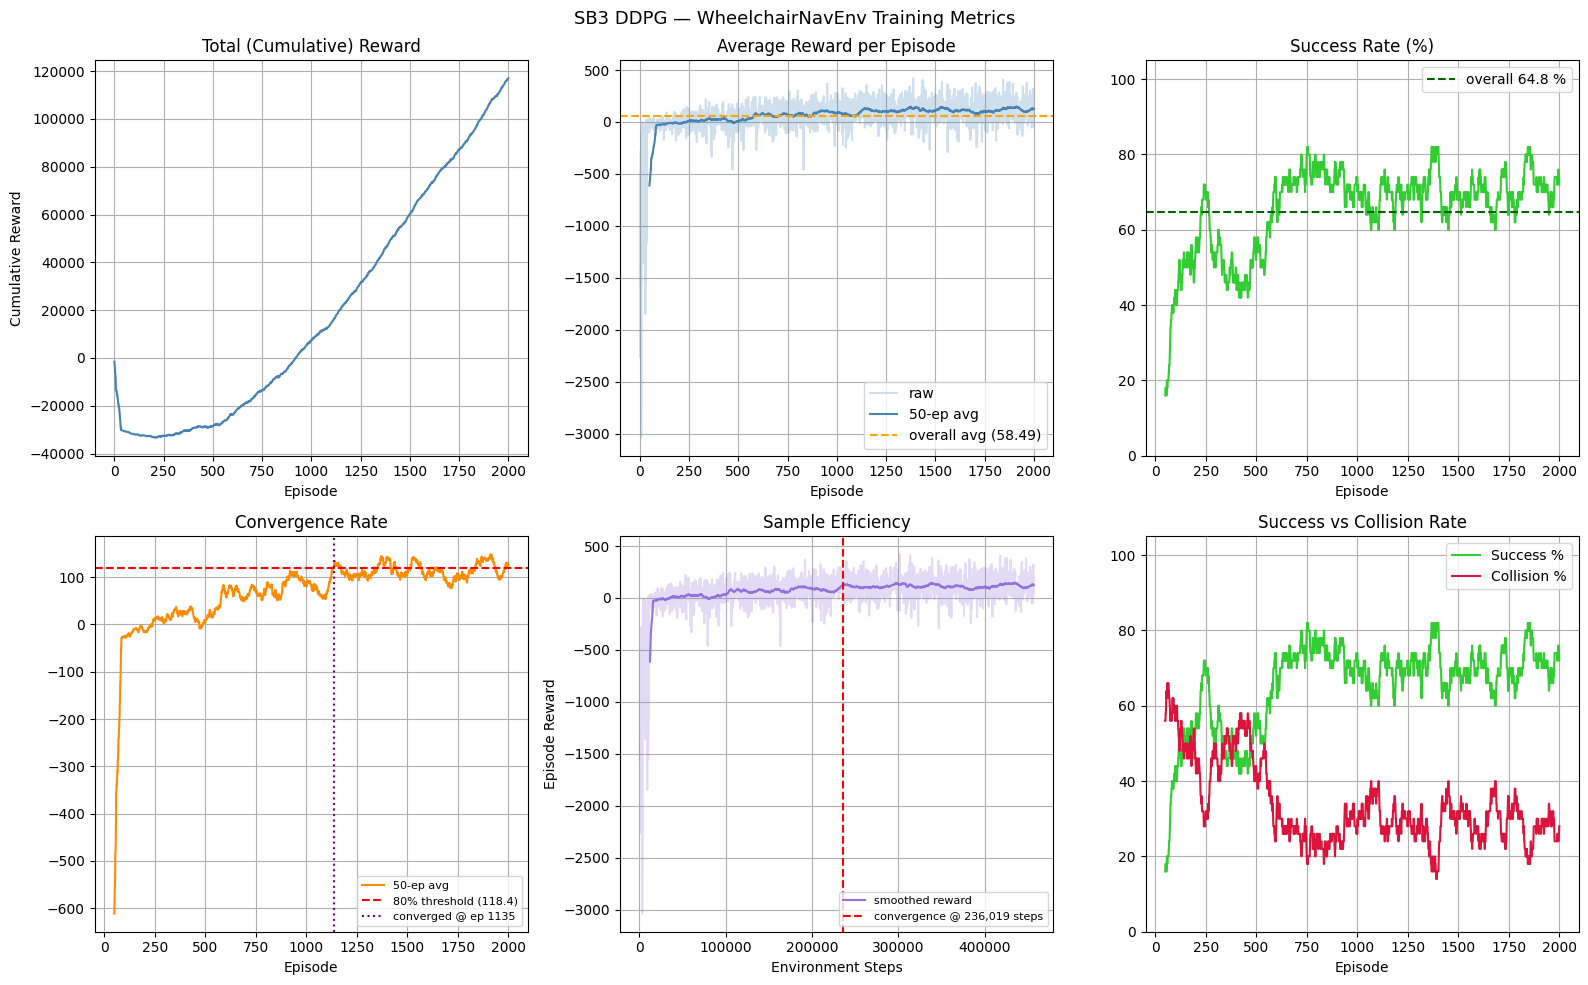

In [ ]:
# ── Evaluation Metrics ───────────────────────────────────────────
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline
episode_rewards  = train_env.get_episode_rewards()   # list[float]
episode_lengths  = train_env.get_episode_lengths()   # list[int]
success_flags    = metrics_cb.success_flags          # list[0|1]
collision_flags  = metrics_cb.collision_flags        # list[0|1]

n_episodes       = len(episode_rewards)
total_timesteps  = sum(episode_lengths)

# ── 1. Total Reward ───────────────────────────────────────────────
# Cumulative reward accumulated across the entire training run.
total_reward = float(np.sum(episode_rewards))

# ── 2. Average Reward ────────────────────────────────────────────
# Mean reward per episode over the full training run.
average_reward = float(np.mean(episode_rewards))

# ── 3. Success Rate ──────────────────────────────────────────────
# Fraction of episodes where the wheelchair reached the goal
# (dist_to_goal <= 0.4 m at termination).
n_success    = int(np.sum(success_flags))
success_rate = float(n_success / n_episodes) if n_episodes > 0 else 0.0

# ── 4. Convergence ──────────────────────────────────────────
CONV_WINDOW = 50
CONV_WINDOW = min(CONV_WINDOW, len(episode_rewards))
CONV_THRESHOLD = 0.80

def smooth(x, w):
    return np.convolve(x, np.ones(w) / w, mode='valid') if len(x) >= w else np.array(x, dtype=float)

smoothed_r      = smooth(episode_rewards, CONV_WINDOW)
peak_smooth     = float(np.max(smoothed_r)) if len(smoothed_r) > 0 else 0.0
threshold_val   = CONV_THRESHOLD * peak_smooth
conv_indices    = np.where(smoothed_r >= threshold_val)[0]
convergence_episode = int(conv_indices[0] + CONV_WINDOW - 1) if len(conv_indices) > 0 else n_episodes
episode_convergence_rate = convergence_episode / n_episodes

# ── 5. Sample Efficiency ─────────────────────────────────────────
# Number of environment timesteps needed to first reach the
# convergence episode.  Fewer steps = more sample-efficient.
steps_to_convergence = int(np.sum(episode_lengths[:convergence_episode + 1]))

# ── Summary ──────────────────────────────────────────────────────
print("=" * 52)
print("  DDPG — WheelchairNavEnv Training Metrics")
print("=" * 52)
print(f"  Episodes trained      : {n_episodes:>10,}")
print(f"  Total timesteps       : {total_timesteps:>10,}")
print(f"  Total Reward          : {total_reward:>10.2f}")
print(f"  Average Reward / ep   : {average_reward:>10.4f}")
print(f"  Success Rate          : {success_rate * 100:>9.2f} %")
print(f"  Convergence Episode   : {convergence_episode:>10,}")
print(f"  Convergence Rate      : {episode_convergence_rate * 100:>9.2f} %")
print(f"  Sample Efficiency     : {steps_to_convergence:>10,}  steps to convergence")
print("=" * 52)

# ── Plots ─────────────────────────────────────────────────────────
window = min(CONV_WINDOW, n_episodes // 2) if n_episodes >= 4 else 2

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

# 1 — Total / Cumulative Reward
cumulative_r = np.cumsum(episode_rewards)
axes[0].plot(cumulative_r, color='steelblue')
axes[0].set_title('Total (Cumulative) Reward')
axes[0].set_xlabel('Episode')
axes[0].set_ylabel('Cumulative Reward')
axes[0].grid(True)

# 2 — Average Reward (smoothed)
sm_r = smooth(episode_rewards, window)
axes[1].plot(episode_rewards, alpha=0.25, color='steelblue', label='raw')
axes[1].plot(range(window - 1, len(episode_rewards)), sm_r,
             color='steelblue', label=f'{window}-ep avg')
axes[1].axhline(average_reward, color='orange', linestyle='--', label=f'overall avg ({average_reward:.2f})')
axes[1].set_title('Average Reward per Episode')
axes[1].set_xlabel('Episode')
axes[1].legend(); axes[1].grid(True)

# 3 — Success Rate (rolling)
sm_sr = smooth(success_flags, window) * 100
axes[2].plot(range(window - 1, len(success_flags)), sm_sr, color='limegreen')
axes[2].axhline(success_rate * 100, color='darkgreen', linestyle='--',
                label=f'overall {success_rate * 100:.1f} %')
axes[2].set_title('Success Rate (%)')
axes[2].set_xlabel('Episode')
axes[2].set_ylim(0, 105)
axes[2].legend(); axes[2].grid(True)

# 4 — Convergence Rate
sm_full = smooth(episode_rewards, CONV_WINDOW)
x_full  = range(CONV_WINDOW - 1, len(episode_rewards))
axes[3].plot(x_full, sm_full, color='darkorange', label=f'{CONV_WINDOW}-ep avg')
axes[3].axhline(threshold_val, color='red', linestyle='--',
                label=f'80% threshold ({threshold_val:.1f})')
axes[3].axvline(convergence_episode, color='purple', linestyle=':',
                label=f'converged @ ep {convergence_episode}')
axes[3].set_title('Convergence Rate')
axes[3].set_xlabel('Episode')
axes[3].legend(fontsize=8); axes[3].grid(True)

# 5 — Sample Efficiency (cumulative steps vs smoothed reward)
cum_steps = np.cumsum(episode_lengths)
axes[4].plot(cum_steps, episode_rewards, alpha=0.25, color='mediumpurple')
axes[4].plot(cum_steps[CONV_WINDOW - 1:], sm_full, color='mediumpurple',
             label='smoothed reward')
axes[4].axvline(steps_to_convergence, color='red', linestyle='--',
                label=f'convergence @ {steps_to_convergence:,} steps')
axes[4].set_title('Sample Efficiency')
axes[4].set_xlabel('Environment Steps')
axes[4].set_ylabel('Episode Reward')
axes[4].legend(fontsize=8); axes[4].grid(True)

# 6 — Success vs Collision
sm_cf = smooth(collision_flags, window) * 100
axes[5].plot(range(window - 1, len(success_flags)),   sm_sr, color='limegreen', label='Success %')
axes[5].plot(range(window - 1, len(collision_flags)), sm_cf, color='crimson',   label='Collision %')
axes[5].set_title('Success vs Collision Rate')
axes[5].set_xlabel('Episode')
axes[5].set_ylim(0, 105)
axes[5].legend(); axes[5].grid(True)

plt.suptitle('SB3 DDPG — WheelchairNavEnv Training Metrics', fontsize=13)
plt.tight_layout()
plt.show()



# **Save metrics**

In [ ]:
import json

# 1. Organize the metrics into a dictionary
metrics_data = {
    "metadata": {
        "algorithm": "DDPG",
        "environment": "WheelchairNavEnv"
    },
    "summary_metrics": {
        "episodes_trained": n_episodes,
        "total_timesteps": total_timesteps,
        "total_reward": round(total_reward, 2),
        "average_reward_per_episode": round(average_reward, 4),
        "success_rate_percentage": round(success_rate * 100, 2),
        "convergence_episode": convergence_episode,
        "steps_to_convergence": steps_to_convergence,
        "convergence_threshold": CONV_THRESHOLD,
        "peak_smoothed_reward": round(peak_smooth, 8)
    },
    "raw_data": {
        "episode_rewards": [float(r) for r in episode_rewards],
        "episode_lengths": [int(l) for l in episode_lengths],
        "success_flags": [int(s) for s in success_flags],
        "collision_flags": [int(c) for c in collision_flags]
    }
}

# 2. Save to a JSON file
file_path = "content/training_metrics.json"
with open(file_path, "w") as f:
    json.dump(metrics_data, f, indent=4)

print(f"\nSuccessfully saved metrics to {file_path}")


Successfully saved metrics to content/training_metrics.json


# **Save Model**

In [ ]:
model.save('content/ddpg_wheelchair_OUv2')

# **Load Model and display Video**

In [ ]:
import io
import os
import matplotlib
matplotlib.use("Agg")
from IPython.display import display, Video
from stable_baselines3 import DDPG
from wheelchair_env import WheelchairNavEnv
import imageio.v2 as imageio
from PIL import Image

# ── Load model ────────────────────────────────────────────────────────────────
model = DDPG.load('content/ddpg_wheelchair_OUv2')

env = WheelchairNavEnv(
    action_type='continuous',
    n_people=3,
    n_obstacles=4,
    render_mode='rgb_array',
    seed=100
)


In [ ]:
# ── Record ────────────────────────────────────────────────────────────────────
N_EPISODES  = 3
OUTPUT_PATH = "video/wheelchair_ddpg.mp4"
FPS         = 24   # increase for faster playback

frames = []

for ep in range(1, N_EPISODES + 1):
    obs, _ = env.reset()
    total_reward = 0.0
    done = False
    step = 0

    while not done:
        action, _ = model.predict(obs, deterministic=True)
        obs, reward, terminated, truncated, info = env.step(action)
        total_reward += reward
        done = terminated or truncated
        step += 1

        raw = env.render()
        if isinstance(raw, bytes):
            from PIL import Image
            import io
            frame = np.array(Image.open(io.BytesIO(raw)))
        else:
            frame = raw
        frames.append(frame)

    outcome = ("✓ GOAL"      if terminated and env._dist_to_goal() < 0.4
               else "✗ COLLISION" if terminated else "⏱ TIMEOUT")
    print(f"Episode {ep}/{N_EPISODES} — {outcome} | steps={step} | total={total_reward:.2f}")

env.close()

# ── Save MP4 ──────────────────────────────────────────────────────────────────
writer = imageio.get_writer(OUTPUT_PATH, fps=FPS, codec="libx264", quality=8)
for frame in frames:
    writer.append_data(frame)
writer.close()

print(f"\nSaved {len(frames)} frames → {OUTPUT_PATH}")
display(Video(OUTPUT_PATH, embed=True, width=900))

Episode 1/3 — ✗ COLLISION | steps=112 | total=125.48
Episode 2/3 — ✗ COLLISION | steps=62 | total=24.70
Episode 3/3 — ✓ GOAL | steps=319 | total=136.58


IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (619, 577) to (624, 592) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).



Saved 493 frames → video/wheelchair_ddpg.mp4
